<a href="https://colab.research.google.com/github/HSE-LAMBDA/DeepGenerativeModels/blob/master/seminars/seminar-9/1.aae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install comet-ml

# import comet_ml in the top of your file
from comet_ml import Experiment

# Add the following code anywhere in your machine learning file
experiment = Experiment(api_key="lODeHEtCf7XLaV6DJrOfugNcA",
                        project_name="hse-gans-aae", workspace="holybayes")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.5/713.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.7/979.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/holybayes/hse-gans-aae/c3fb85a6097645b6aebc226fad9d5c2a



In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from torch.autograd import Variable
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader



In [9]:

# Batch size for training
batch_size = 256

# Define image transformations
transform = transforms.Compose([
    transforms.Resize(64),  # Resize images to 64x64 resolution
    transforms.ToTensor(),  # Convert images to PyTorch tensors (values in range [0,1])
    # Uncomment the line below to normalize images to the range [-1,1] (common in GANs)
    # transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
dataset = datasets.CIFAR10(
    root="./data",  # Store dataset in the 'data' folder
    train=True,  # Load the training set
    transform=transform,  # Apply transformations to images
    download=True  # Download dataset if not available
)

# Create DataLoader for batch processing
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,  # Shuffle data for better training
    num_workers=2,  # Number of CPU threads for loading data (adjustable based on system)
    drop_last=True  # Drop last batch if it's smaller than batch_size (ensures consistency)
)


Files already downloaded and verified


In [16]:

# Check if a GPU is available and set the computation device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
learning_rate = 1e-4  # Learning rate for optimizers
image_channels = 3     # Number of channels in input images (RGB = 3)
latent_dim = 64        # Dimension of the latent space (z)
generator_filters = 64 # Number of filters in the decoder (generator)
encoder_filters = 64   # Number of filters in the encoder
discriminator_hidden_dim = 128  # Hidden layer size for the discriminator
regularization_coefficient = 1  # Weight for regularization loss

# ----------------------------
#  Decoder (Generator)
# ----------------------------
class Decoder(nn.Module):
    """
    The Decoder (Generator) reconstructs images from the latent space representation.
    This uses transposed convolutional layers to upscale the latent representation.
    """
    def __init__(self):
        super(Decoder, self).__init__()
        self.layers = nn.Sequential(
            # Input: Latent vector (z)
            nn.ConvTranspose2d(latent_dim, generator_filters * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(generator_filters * 8),
            nn.ReLU(True),

            # Upsample to (generator_filters*4) x 8 x 8
            nn.ConvTranspose2d(generator_filters * 8, generator_filters * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(generator_filters * 4),
            nn.ReLU(True),

            # Upsample to (generator_filters*2) x 16 x 16
            nn.ConvTranspose2d(generator_filters * 4, generator_filters * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(generator_filters * 2),
            nn.ReLU(True),

            # Upsample to (generator_filters) x 32 x 32
            nn.ConvTranspose2d(generator_filters * 2, generator_filters, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(generator_filters),
            nn.ReLU(True),

            # Upsample to (image_channels) x 64 x 64
            nn.ConvTranspose2d(generator_filters, image_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Sigmoid()  # Output values between 0 and 1 for images
        )

    def forward(self, x):
        return self.layers(x)

# ----------------------------
#  Encoder
# ----------------------------
class Encoder(nn.Module):
    """
    The Encoder maps input images to a lower-dimensional latent space representation.
    """
    def __init__(self):
        super(Encoder, self).__init__()
        self.layers = nn.Sequential(
            # Input: (image_channels) x 64 x 64
            nn.Conv2d(image_channels, encoder_filters, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Downsample to (encoder_filters*2) x 16 x 16
            nn.Conv2d(encoder_filters, encoder_filters * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(encoder_filters * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Downsample to (encoder_filters*4) x 8 x 8
            nn.Conv2d(encoder_filters * 2, encoder_filters * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(encoder_filters * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Downsample to (encoder_filters*8) x 4 x 4
            nn.Conv2d(encoder_filters * 4, encoder_filters * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(encoder_filters * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: latent space vector of size (latent_dim)
            nn.Conv2d(encoder_filters * 8, latent_dim, kernel_size=4, stride=1, padding=0, bias=False)
        )

    def forward(self, x):
        return self.layers(x)

# ----------------------------
#  Discriminator
# ----------------------------
class Discriminator(nn.Module):
    """
    The Discriminator attempts to classify whether a given latent vector comes from
    the real distribution (prior) or was generated by the encoder.
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, discriminator_hidden_dim),
            nn.ReLU(),
            nn.Linear(discriminator_hidden_dim, 1),
            nn.Sigmoid()  # Output probability (0 = fake, 1 = real)
        )

    def forward(self, x):
        return self.layers(x)

# ----------------------------
#  Initialize Models
# ----------------------------
encoder = Encoder().to(device)
decoder = Decoder().to(device)
discriminator = Discriminator().to(device)

# ----------------------------
#  Utility Functions
# ----------------------------
def reset_grad():
    """
    Resets the gradients for all networks to prepare for the next optimization step.
    """
    encoder.zero_grad()
    decoder.zero_grad()
    discriminator.zero_grad()


Epoch [0/100000], Batch [0], Reconstruction Loss: 0.0942, Discriminator Loss: -0.0005, Generator Loss: -0.4997


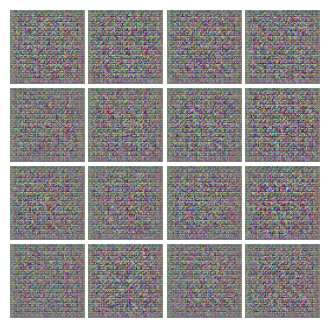

Epoch [0/100000], Batch [100], Reconstruction Loss: 0.0284, Discriminator Loss: 0.0035, Generator Loss: -0.5018


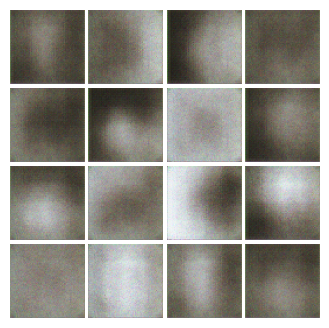

Epoch [1/100000], Batch [0], Reconstruction Loss: 0.0229, Discriminator Loss: 0.0009, Generator Loss: -0.4988


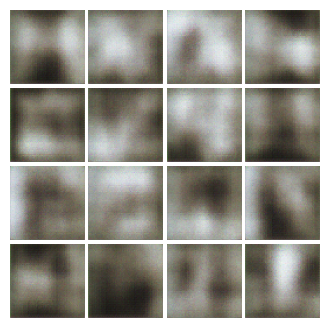

Epoch [1/100000], Batch [100], Reconstruction Loss: 0.0196, Discriminator Loss: 0.0011, Generator Loss: -0.4983


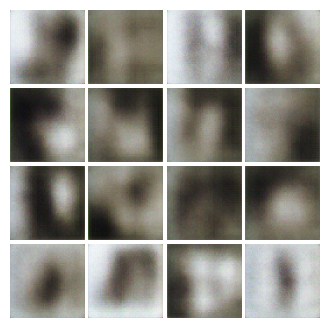

Epoch [2/100000], Batch [0], Reconstruction Loss: 0.0167, Discriminator Loss: 0.0017, Generator Loss: -0.4986


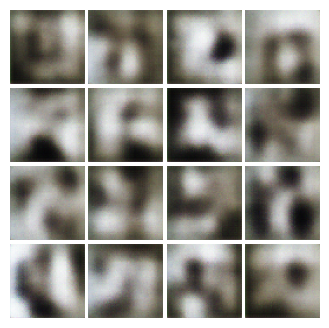

Epoch [2/100000], Batch [100], Reconstruction Loss: 0.0130, Discriminator Loss: 0.0012, Generator Loss: -0.4982


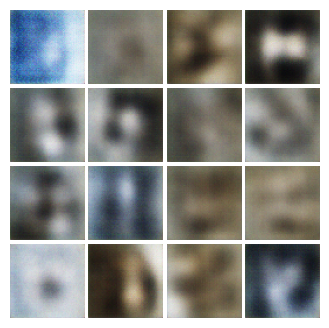

Epoch [3/100000], Batch [0], Reconstruction Loss: 0.0118, Discriminator Loss: 0.0017, Generator Loss: -0.4989


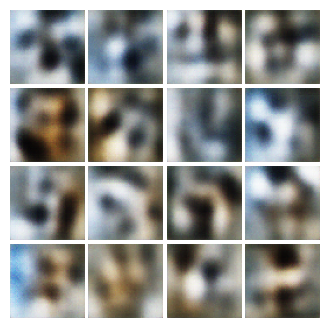

Epoch [3/100000], Batch [100], Reconstruction Loss: 0.0111, Discriminator Loss: 0.0013, Generator Loss: -0.4989


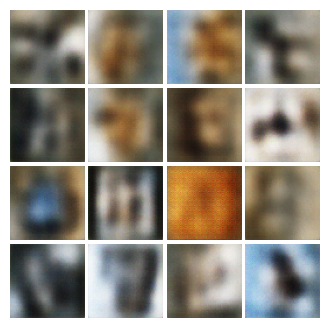

Epoch [4/100000], Batch [0], Reconstruction Loss: 0.0096, Discriminator Loss: 0.0009, Generator Loss: -0.4990


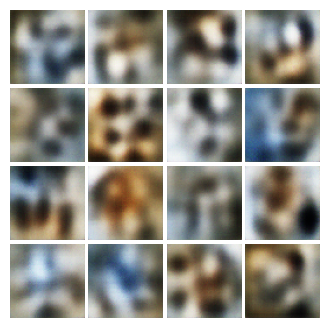

Epoch [4/100000], Batch [100], Reconstruction Loss: 0.0093, Discriminator Loss: 0.0003, Generator Loss: -0.4990


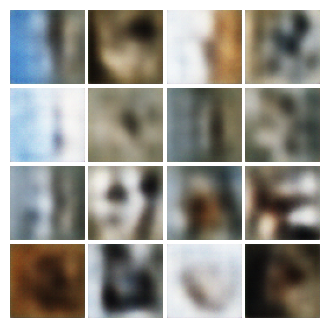

Epoch [5/100000], Batch [0], Reconstruction Loss: 0.0085, Discriminator Loss: 0.0003, Generator Loss: -0.4993


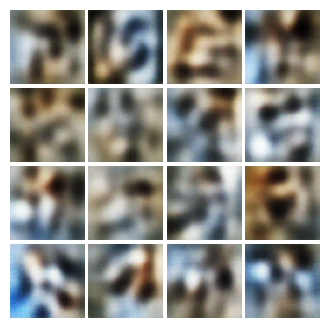

Epoch [5/100000], Batch [100], Reconstruction Loss: 0.0087, Discriminator Loss: 0.0001, Generator Loss: -0.4990


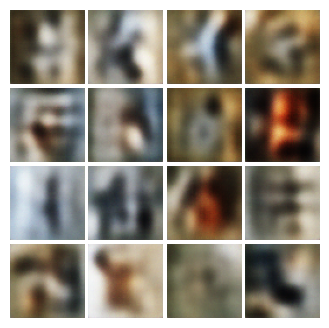

Epoch [6/100000], Batch [0], Reconstruction Loss: 0.0079, Discriminator Loss: 0.0000, Generator Loss: -0.4988


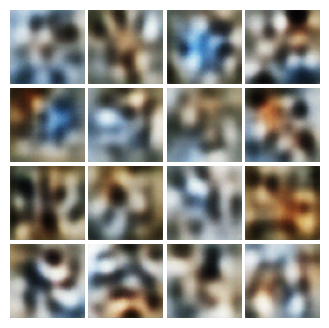

KeyboardInterrupt: 

In [17]:


# Define optimizers for each network
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate * 0.1)  # Lower learning rate for stability

# Number of training iterations
num_epochs = 100000

# Training loop
for epoch in range(num_epochs):

    for batch_idx, (real_images, _) in enumerate(train_loader):
        """ ===== Reconstruction Phase (Autoencoder Training) ===== """

        # Move images to device (CPU/GPU)
        real_images = real_images.to(device)

        # Encode images into latent space
        latent_vectors = encoder(real_images)

        # Decode latent vectors back to images
        reconstructed_images = decoder(latent_vectors)

        # Compute reconstruction loss (Mean Squared Error)
        reconstruction_loss = F.mse_loss(reconstructed_images, real_images)

        # Backpropagation
        reconstruction_loss.backward()
        decoder_optimizer.step()
        encoder_optimizer.step()

        # Reset gradients
        reset_grad()

        """ ===== Regularization Phase (Adversarial Training) ===== """

        # Train Discriminator (Distinguish real vs fake latent vectors)
        for _ in range(5):
            real_latent_vectors = torch.randn(batch_size, latent_dim).to(device)  # Sample from Gaussian prior
            fake_latent_vectors = encoder(real_images).view(batch_size, -1)  # Encode real images

            real_predictions = discriminator(real_latent_vectors)
            fake_predictions = discriminator(fake_latent_vectors)

            # Compute Wasserstein loss (critic loss for WGAN)
            discriminator_loss = -(torch.mean(real_predictions) - torch.mean(fake_predictions))

            # Backpropagation
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # Optional: Weight clipping (only for WGAN without gradient penalty)
            for p in discriminator.parameters():
                p.data.clamp_(-0.01, 0.01)

            # Reset gradients
            reset_grad()

        """ ===== Train Generator (Encoder) to Fool Discriminator ===== """

        fake_latent_vectors = encoder(real_images).view(batch_size, -1)
        fake_predictions = discriminator(fake_latent_vectors)

        # Generator (Encoder) loss: Try to fool the discriminator
        generator_loss = -torch.mean(fake_predictions)

        # Backpropagation
        generator_loss.backward()
        encoder_optimizer.step()

        # Reset gradients
        reset_grad()

        """ ===== Logging and Visualization ===== """
        # Log metrics every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Batch [{batch_idx}], "
                  f"Reconstruction Loss: {reconstruction_loss.item():.4f}, "
                  f"Discriminator Loss: {discriminator_loss.item():.4f}, "
                  f"Generator Loss: {generator_loss.item():.4f}")

            # Generate images for visualization
            real_latent_vectors = real_latent_vectors.unsqueeze(2).unsqueeze(3)  # Expand dimensions for decoder

            # Alternate between generated and reconstructed images
            if batch_idx % 200 == 0:
                samples = decoder(real_latent_vectors).cpu().data.numpy()[:16]  # Generate images
            else:
                samples = reconstructed_images.cpu().data.numpy()[:16]  # Show reconstructed images

            # Plot samples
            plt.figure(figsize=(4, 4))
            grid = gridspec.GridSpec(4, 4)
            grid.update(wspace=0.05, hspace=0.05)

            for i, sample in enumerate(samples):
                ax = plt.subplot(grid[i])
                plt.axis('off')
                ax.set_xticklabels([])
                ax.set_yticklabels([])
                ax.set_aspect('equal')
                sample = np.swapaxes(sample, 0, 2)  # Rearrange dimensions for plotting
                plt.imshow(sample)

            # Log images (replace experiment.log_figure if using another logging tool)
            plt.savefig(f"output_epoch_{epoch}_batch_{batch_idx}.png")
            plt.show()
            plt.close()


In [13]:
samples[0]

array([[[0.8008865 , 0.8629761 , 0.88387793, ..., 0.64879066,
         0.6808559 , 0.65790766],
        [0.84319305, 0.88830537, 0.8916177 , ..., 0.65896463,
         0.6624914 , 0.6440082 ],
        [0.8492908 , 0.88535595, 0.9021018 , ..., 0.61317694,
         0.635537  , 0.66160464],
        ...,
        [0.64780104, 0.66423225, 0.62927604, ..., 0.9071678 ,
         0.90401524, 0.88656265],
        [0.6603635 , 0.6488034 , 0.62220967, ..., 0.80527526,
         0.91193765, 0.8682199 ],
        [0.60107666, 0.6067661 , 0.6163686 , ..., 0.8582835 ,
         0.86716604, 0.79394704]],

       [[0.82162404, 0.92986697, 0.8877607 , ..., 0.7651066 ,
         0.7508217 , 0.7141963 ],
        [0.89998865, 0.9499035 , 0.92818815, ..., 0.723801  ,
         0.73684937, 0.7543806 ],
        [0.89898115, 0.9297867 , 0.9388413 , ..., 0.82004076,
         0.763955  , 0.75365543],
        ...,
        [0.6173133 , 0.6198456 , 0.5992    , ..., 0.95042115,
         0.92870635, 0.9159283 ],
        [0.6

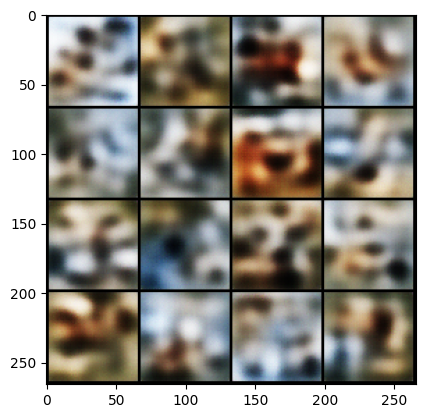

In [14]:
from torchvision.utils import make_grid
plt.imshow(make_grid(torch.from_numpy(samples), 4).permute(1,2,0))
